In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/akash/Downloads/orders.csv')
print("Shape:", df.shape)
#df.head()

Shape: (9994, 16)


In [4]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Order Id          9994 non-null   int64 
 1   Order Date        9994 non-null   object
 2   Ship Mode         9993 non-null   object
 3   Segment           9994 non-null   object
 4   Country           9994 non-null   object
 5   City              9994 non-null   object
 6   State             9994 non-null   object
 7   Postal Code       9994 non-null   int64 
 8   Region            9994 non-null   object
 9   Category          9994 non-null   object
 10  Sub Category      9994 non-null   object
 11  Product Id        9994 non-null   object
 12  cost price        9994 non-null   int64 
 13  List Price        9994 non-null   int64 
 14  Quantity          9994 non-null   int64 
 15  Discount Percent  9994 non-null   int64 
dtypes: int64(6), object(10)
memory usage: 1.2+ MB


,Order Id,Postal Code,cost price,List Price,Quantity,Discount Percent
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,201.189714,229.756854,3.789574,3.484090
std,2885.163629,32063.693350,537.743203,623.245839,2.225110,1.114211
min,1.000000,1040.000000,0.000000,0.000000,1.000000,2.000000
25%,2499.250000,23223.000000,20.000000,20.000000,2.000000,2.000000
50%,4997.500000,56430.500000,50.000000,50.000000,3.000000,3.000000
75%,7495.750000,90008.000000,180.000000,210.000000,5.000000,4.000000
max,9994.000000,99301.000000,18110.000000,22640.000000,14.000000,5.000000


In [5]:
# Drop nulls
df.dropna(inplace=True)

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract month & year
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

print("Cleaned! Shape:", df.shape)

Cleaned! Shape: (9993, 18)


In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Sale Price'] = df['List Price'] * (1 - df['Discount Percent']/100)
df['Revenue'] = df['Sale Price'] * df['Quantity']
df['Profit'] = (df['Sale Price'] - df['cost price']) * df['Quantity']
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df.dropna(inplace=True)

print("Cleaned! Shape:", df.shape)
df.head()

Cleaned! Shape: (9993, 21)


,Order Id,Order Date,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub Category,Product Id,cost price,List Price,Quantity,Discount Percent,Month,Year,Sale Price,Revenue,Profit
0,1,2023-03-01,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,FUR-BO-10001798,240,260,2,2,3,2023,254.8,509.6,29.6
1,2,2023-08-15,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,FUR-CH-10000454,600,730,3,3,8,2023,708.1,2124.3,324.3
2,3,2023-01-10,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,OFF-LA-10000240,10,10,2,5,1,2023,9.5,19.0,-1.0
3,4,2022-06-18,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,FUR-TA-10000577,780,960,5,2,6,2022,940.8,4704.0,804.0
4,5,2022-07-13,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,OFF-ST-10000760,20,20,2,5,7,2022,19.0,38.0,-2.0


In [8]:
print("===== KEY BUSINESS METRICS =====")
print(f"Total Revenue   : ${df['Revenue'].sum():,.0f}")
print(f"Total Profit    : ${df['Profit'].sum():,.0f}")
print(f"Total Orders    : {len(df):,}")
print(f"Avg Order Value : ${df['Revenue'].mean():,.0f}")
print(f"Profit Margin   : {df['Profit'].sum()/df['Revenue'].sum()*100:.1f}%")


===== KEY BUSINESS METRICS =====
Total Revenue   : $11,079,176
Total Profit    : $1,039,916
Total Orders    : 9,993
Avg Order Value : $1,109
Profit Margin   : 9.4%


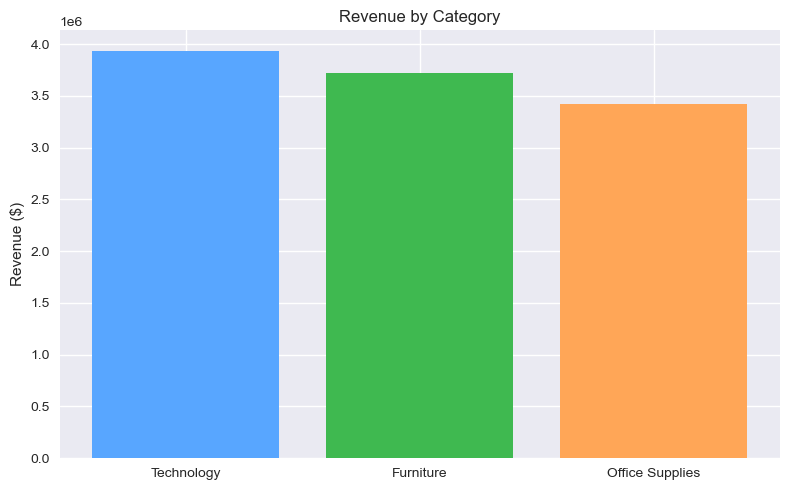

In [9]:
cat_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(cat_rev.index, cat_rev.values, color=['#58a6ff','#3fb950','#ffa657'])
plt.title('Revenue by Category')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('category_revenue.png')
plt.show()

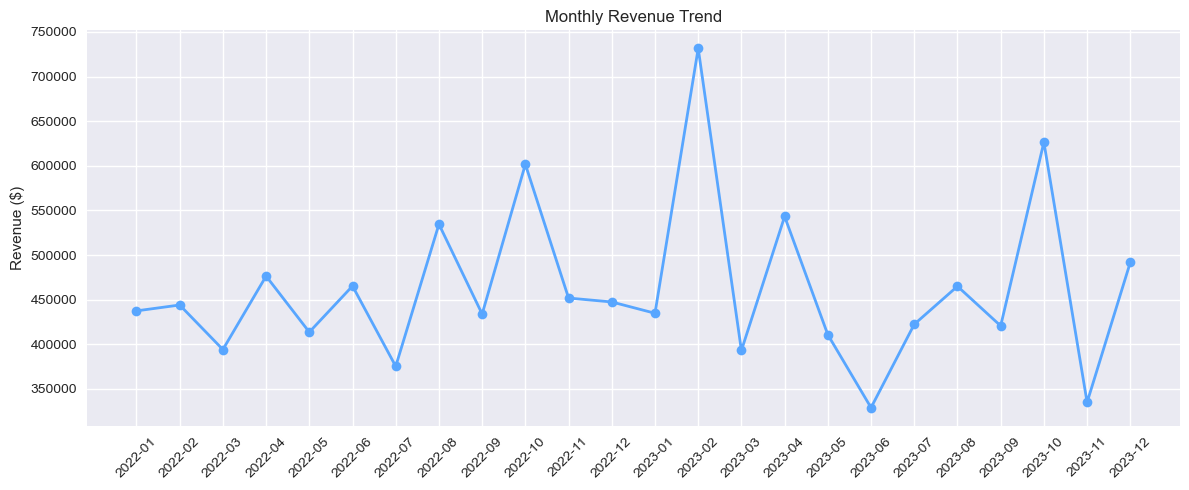

In [10]:
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)

plt.figure(figsize=(12,5))
plt.plot(monthly['Period'], monthly['Revenue'], marker='o', color='#58a6ff', linewidth=2)
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

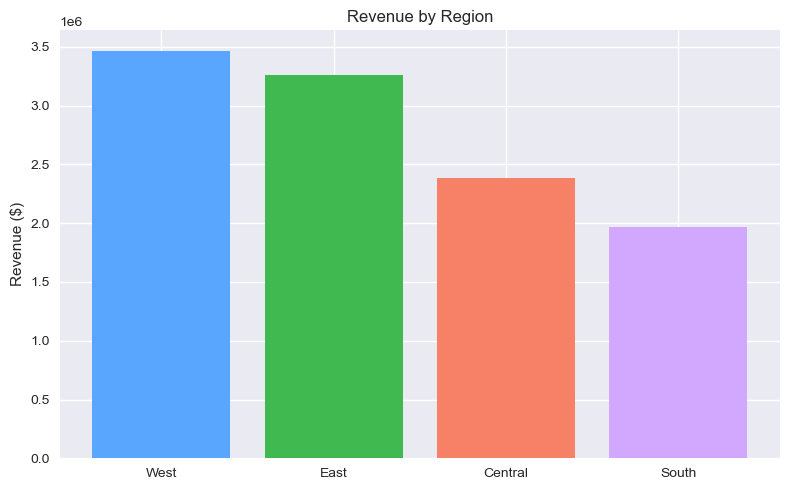

In [11]:
reg_rev = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(reg_rev.index, reg_rev.values, color=['#58a6ff','#3fb950','#f78166','#d2a8ff'])
plt.title('Revenue by Region')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('region_revenue.png')
plt.show()

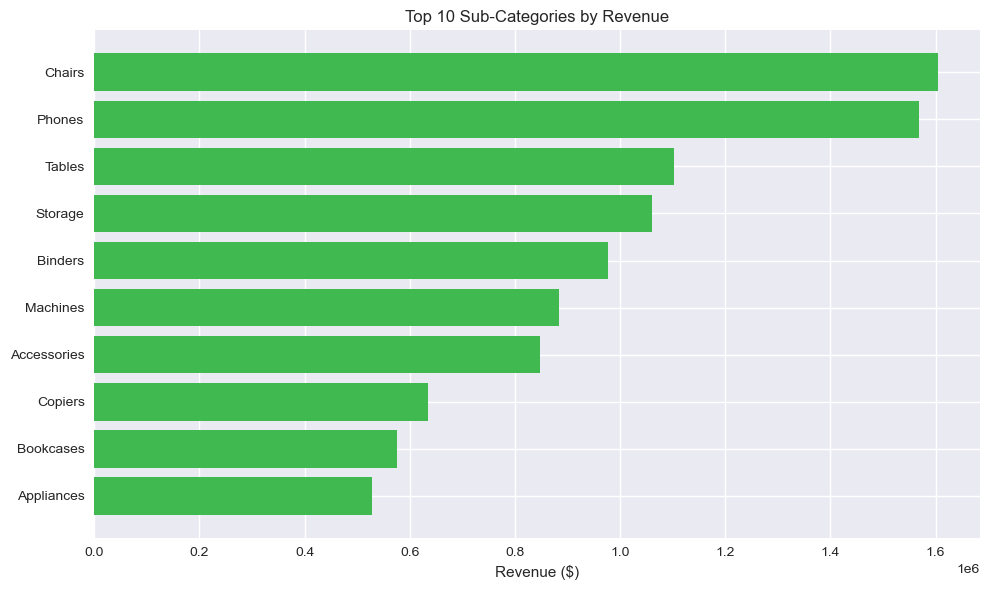

In [12]:
top_sub = df.groupby('Sub Category')['Revenue'].sum().sort_values().tail(10)

plt.figure(figsize=(10,6))
plt.barh(top_sub.index, top_sub.values, color='#3fb950')
plt.title('Top 10 Sub-Categories by Revenue')
plt.xlabel('Revenue ($)')
plt.tight_layout()
plt.savefig('top_subcategories.png')
plt.show()

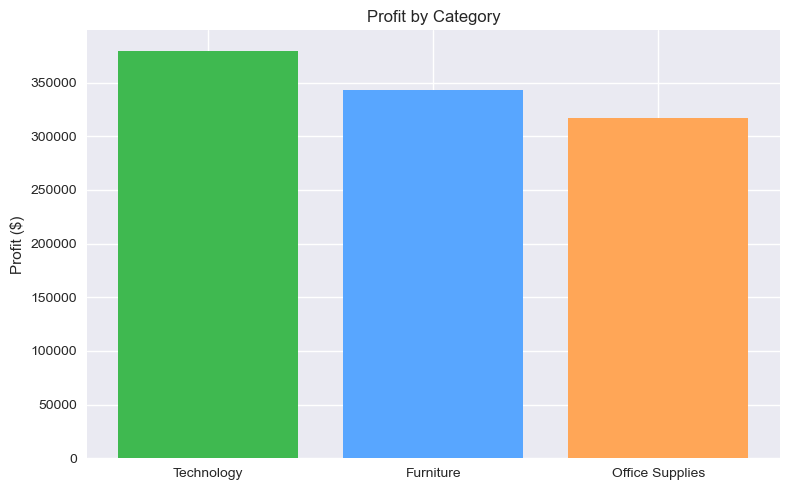

In [13]:
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(cat_profit.index, cat_profit.values, color=['#3fb950','#58a6ff','#ffa657'])
plt.title('Profit by Category')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('profit_category.png')
plt.show()